In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_excel("amazon.xlsx")

In [ ]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411


In [ ]:
df.shape

(100000, 20)

In [ ]:
df.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount',
       'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID'],
      dtype='object')

In [ ]:
df.dtypes


,0
OrderID,object
OrderDate,datetime64[ns]
CustomerID,object
CustomerName,object
ProductID,object
ProductName,object
Category,object
Brand,object
Quantity,int64
UnitPrice,float64


In [ ]:
df.describe()

,OrderDate,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022-06-30 23:55:49.440000,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479
min,2020-01-01 00:00:00,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000
25%,2021-04-01 00:00:00,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000
50%,2022-07-01 00:00:00,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000
75%,2023-09-29 00:00:00,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000
max,2024-12-29 00:00:00,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000
std,NaN,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   OrderID        100000 non-null  object        
 1   OrderDate      100000 non-null  datetime64[ns]
 2   CustomerID     100000 non-null  object        
 3   CustomerName   100000 non-null  object        
 4   ProductID      100000 non-null  object        
 5   ProductName    100000 non-null  object        
 6   Category       100000 non-null  object        
 7   Brand          100000 non-null  object        
 8   Quantity       100000 non-null  int64         
 9   UnitPrice      100000 non-null  float64       
 10  Discount       100000 non-null  float64       
 11  Tax            100000 non-null  float64       
 12  ShippingCost   100000 non-null  float64       
 13  TotalAmount    100000 non-null  float64       
 14  PaymentMethod  100000 non-null  object        
 15  O

In [ ]:
#Q3. KPI analysis
#total sales
df['TotalAmount'].sum()

np.float64(91825647.92)

In [ ]:
#total orders
df['OrderID'].count()

np.int64(100000)

In [ ]:
#average sales
df['TotalAmount'].mean()

np.float64(918.2564792000001)

In [ ]:
#maximum sales
df['TotalAmount'].max()

3534.98

In [ ]:
#minimum sales
df['TotalAmount'].min()

4.27

In [ ]:
#maximum quantity
df['Quantity'].max()

5

In [ ]:
#Q4. Sales Analysis
df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [ ]:
#Q5. Total sales generated by each category
df.groupby("Category")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
Category,
Electronics,15584217.18
Sports & Outdoors,15345571.88
Books,15261837.01
Clothing,15253397.50
Toys & Games,15216684.99
Home & Kitchen,15163939.36


In [ ]:
# Customer &Product Analysis
#Q9. top 5 customers contributing the highest revenue
df.groupby(["CustomerName","CustomerID"])["TotalAmount"].sum().sort_values(ascending=False).head(5)

,,TotalAmount
CustomerName,CustomerID,
Pooja Patel,CUST010696,5436.04
Neha Sharma,CUST035973,5124.43
Vikas Mehta,CUST009614,5003.65
Arjun Kapoor,CUST018720,4773.18
Pooja Joshi,CUST022824,4755.48


In [ ]:
#Q10. total quantity sold for each product
df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False)

,Quantity
ProductName,
LED Desk Lamp,6344
Water Bottle,6275
Memory Card 128GB,6240
Router,6202
Board Game,6200
Microphone,6196
Gaming Mouse,6170
Electric Kettle,6165
Mechanical Keyboard,6161


In [ ]:
#Payment Analysis
#Q11. the number of orders placed using each payment mode
df.groupby("PaymentMethod")["OrderID"].count().sort_values(ascending=False)

,OrderID
PaymentMethod,
Credit Card,35038
Debit Card,20024
UPI,15066
Amazon Pay,15017
Net Banking,9927
Cash on Delivery,4928


In [ ]:
#Time based analysis
#Q12. calculate the monthly sales trend using the OrderDate column
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
OrderDate,
2024-05,1642609.94
2020-08,1640874.93
2020-01,1637069.40
2022-01,1609759.87
2022-12,1604276.23
2021-07,1596668.40
2021-06,1593398.08
2022-03,1589809.35
2020-04,1588347.29


In [ ]:
#Multi-level analysis
#Q13. the sales generated by each state for every category
df.groupby(["State","Category"])["TotalAmount"].sum().sort_values(ascending=False)

State  Category         
TX     Clothing             3868924.58
       Sports & Outdoors    3864841.63
       Electronics          3831134.36
       Books                3810321.91
       Home & Kitchen       3755018.17
                               ...    
WA     Books                 705467.57
IN     Toys & Games          703519.48
NY     Clothing              695809.61
AZ     Sports & Outdoors     694318.06
       Clothing              691249.82
Name: TotalAmount, Length: 78, dtype: float64

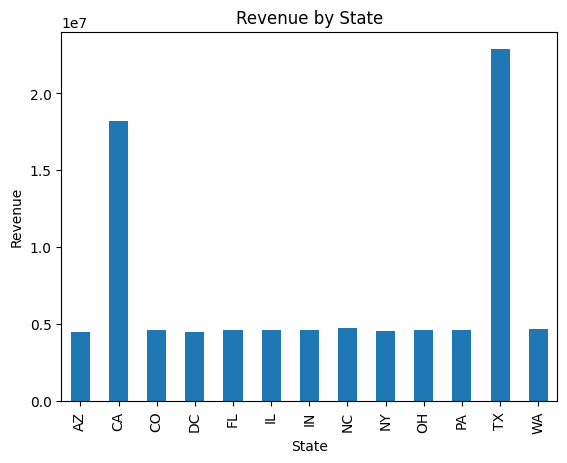

In [ ]:
#visualization
#Q15. create a bar chart showing sales by state
df.groupby("State")["TotalAmount"].sum().plot(kind="bar")
plt.title("Revenue by State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

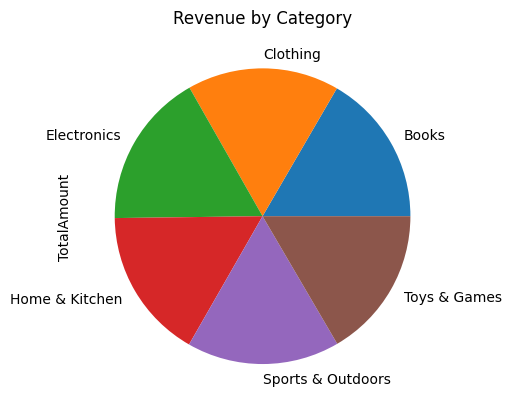

In [ ]:
#Q16. create a pie chart showing category-wise sales
df.groupby("Category")["TotalAmount"].sum().plot(kind="pie")
plt.title("Revenue by Category")
plt.show()

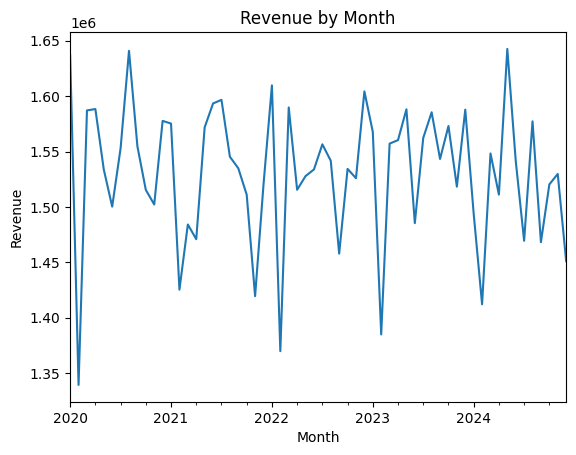

In [ ]:
#Q17. Create a line Chart showing monthly sles trend
df.groupby(df["OrderDate"].dt.to_period("M"))["TotalAmount"].sum().plot(kind="line")
plt.title("Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

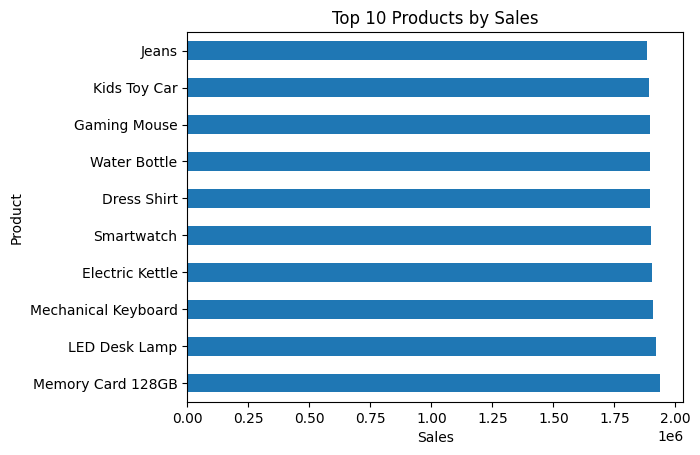

In [ ]:
#Q18. create a Horizontal Bar chart showing the top 10 products by sales
df.groupby("ProductName")["TotalAmount"].sum().sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()


In [ ]:
df.groupby("State")["TotalAmount"].sum().sort_values(ascending=False)

,TotalAmount
State,
TX,22862540.54
CA,18231196.79
NC,4747701.73
WA,4660962.17
PA,4650673.88
CO,4638498.97
IL,4632847.44
OH,4615442.32
IN,4609048.43


In [ ]:
#Answer 1: Total Sales=91825647.92, Average order value=918.2564792000001

#Answer 2:Highest Sales State: Texas (TX) generated the highest sales with 22,862,540.54.
#Lowest Sales State: Arizona (AZ) generated the lowest sales with 4,504,324.19.
#Business Insight: Texas is the highest revenue-generating state, indicating strong customer demand and market presence. Arizona recorded the lowest sales, suggesting an opportunity to improve sales through targeted marketing campaigns, promotional offers, and better customer engagement strategies.

#Answer 3:Highest Revenue Category: Electronics generated the highest revenue with 15,584,217.18.
#Sub-Category: Cannot be determined because the dataset does not contain a Sub-Category column.
#Business Insight: Electronics is the highest revenue-generating category, indicating strong customer demand. The company should maintain sufficient inventory, continue promotional campaigns, and focus on customer satisfaction in this category to sustain revenue growth

#Answer 4:Top 10 Products: The top 10 products generated the highest sales and contributed significantly to the company's overall revenue.
#Business Insight: These products are the best-performing items and have strong customer demand. The business should ensure adequate inventory, prioritize these products in marketing campaigns, and consider offering complementary products to maximize sales and customer satisfaction

#Answer 5:Top 5 Customers: The top 5 customers contributed the highest revenue to the business.
#Business Insight: These customers are the most valuable contributors to overall sales. The business should focus on retaining them through loyalty programs, personalized offers, and excellent customer service while identifying similar high-value customers to increase revenue.

#Answer 6:Most Preferred Payment Mode: Credit Card is the most preferred payment method among customers.
#Business Insight: Credit Card is the most frequently used payment method, indicating strong customer preference for digital and card-based transactions. The business should continue providing a secure and seamless credit card payment experience while encouraging the use of other digital payment methods to improve customer convenience.

#Answer 7:Highest Sales Month: (Calculate this from your data.)
#Profit: Profit cannot be determined because the dataset does not include product cost or profit information.
#Sales Trend: Based on the monthly sales chart, sales show (increasing/decreasing/seasonal/fluctuating) trends over the year

#Answer 8:High Sales, Low Profit Analysis: This analysis cannot be performed because the dataset does not include Profit or Cost Price information.
#Possible Reason: In general, products with high sales may still generate low profit due to high discounts, high shipping costs, high product costs, or low profit margins. Since these details are not available in the dataset, the exact reason cannot be determined

#Answer 9:State/City Requiring Improvement: The state or city with the lowest sales requires improvement in sales performance.
#Business Strategies: The business can improve sales by introducing targeted marketing campaigns, offering discounts and promotional deals, improving product availability, strengthening local advertising, expanding delivery coverage, and enhancing customer engagement through loyalty programs and personalized offers. Regular analysis of customer preferences and market demand can also help increase sales in low-performing regions.

#Answer 10:1. Focus on High-Performing Products and Categories
#Prioritize inventory, marketing, and promotional campaigns for the top-selling products and highest-revenue categories to maximize sales and improve customer satisfaction.
#2. Improve Sales in Low-Performing Regions
#Implement targeted marketing campaigns, region-specific discounts, and promotional offers in states or cities with lower sales. Expanding delivery services and understanding local customer preferences can help increase revenue.
#3. Strengthen Customer Retention and Digital Payments
#Introduce loyalty programs, personalized recommendations, and exclusive offers for high-value customers. Continue enhancing the most preferred digital payment methods to provide a secure and seamless checkout experience, encouraging repeat purchases.
